# Who's that butterfly?

**Students:** Yuval Cohen & Inbar Rotshtein

This project aims to develop a robust and accurate system for identifying different species of butterflies from images.

### The Importance of Butterflies and the Problem We're Solving:

Butterflies are not just beautiful; they are vital components of healthy ecosystems. They serve as crucial pollinators, supporting plant reproduction and biodiversity. Furthermore, they are sensitive indicators of environmental change, and tracking their populations provides valuable insights into the health of our natural world.

However, identifying the vast array of butterfly species can be challenging, even for experts. Manual identification is time-consuming and requires specialized knowledge, creating a bottleneck for large-scale ecological studies, conservation efforts, and citizen science initiatives. This difficulty in accurate and efficient identification is the core problem our project addresses.

### The Significance of Our Solution:

Our project offers a powerful solution by using advanced computer vision to automatically identify butterfly species from images. This means we can:

*   **Collect Data Faster:** Quickly and efficiently gather information about butterfly populations, allowing researchers to cover more ground and track changes over time.
*   **Involve More People:** Create tools that allow anyone, from seasoned scientists to nature enthusiasts, to easily identify butterflies and contribute valuable data to conservation efforts.
*   **Boost Conservation:** Provide essential information needed to understand where different butterfly species live, what they need to survive, and how best to protect those that are at risk.
*   **Ensure Reliability:** Build a system that is rigorously tested to make sure its identifications are accurate and trustworthy.

By automating butterfly identification with a reliable system, we make it easier to study and protect these important creatures, contributing to the health of our planet's biodiversity.

### About the Project:

This project explores different machine learning approaches for the challenging task of butterfly species identification from images. We will be comparing the performance of several models to determine the most effective method for this task.

Our project will investigate the following approaches:

1.  **Classic Models on Raw Images:** We will train basic classification models like Logistic Regression and Support Vector Machines (SVM) directly on the raw pixel data of the butterfly images. This will serve as a baseline to understand the performance of simpler models on this complex visual task.

2.  **Convolutional Neural Network (CNN):** We will develop and train a Convolutional Neural Network (CNN) on the raw image data. CNNs are well-suited for image tasks as they can automatically learn hierarchical features from the pixels.

3.  **Fine-tuned CLIP with Classic Classifiers:** We will leverage the power of a pre-trained vision-language model called CLIP. We will fine-tune the image encoder part of CLIP on our butterfly dataset. The fine-tuned CLIP model will then be used to extract rich feature representations (embeddings) for each image. Finally, we will train classic classifiers, including SVM, K-Nearest Neighbors (KNN), and Logistic Regression, on these extracted CLIP embeddings. This approach combines the benefits of powerful pre-trained models with the interpretability and efficiency of classic classifiers.

By comparing these different architectures and approaches, we aim to identify the most accurate and efficient method for identifying butterfly species from images.

### Dataset Description:

The dataset used in this project is sourced from [https://www.kaggle.com/datasets/phucthaiv02/butterfly-image-classification?select=test](https://www.kaggle.com/datasets/phucthaiv02/butterfly-image-classification?select=test).

It consists of over 6000 images, representing 75 different species (classes) of butterflies.

A notable characteristic of this dataset is the significant variability within the images. The photos can differ widely in terms of:

*   **Angle and Pose:** Butterflies are captured from various angles and in different poses.
*   **Backgrounds:** The images feature diverse backgrounds, ranging from natural environments to staged settings.
*   **Lighting Conditions:** Lighting can vary, impacting the appearance of the butterflies.
*   **Image Quality:** The resolution and clarity of the images are not uniform.
*   **Partial Views and Occlusions:** Some images may only show a part of the butterfly or have parts obscured.

This inherent variability makes the task of accurate identification more challenging and serves as a good test for the robustness of our different modeling approaches.

# Imports

In [ ]:
!pip install open_clip_torch -q
!pip install scikit-image -q
!pip install torch torchvision -q

In [ ]:
import os
import csv
import copy
import warnings
from typing import List, Tuple, Dict
from collections import Counter, defaultdict
import random
import time

import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError
import cv2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.preprocessing import LabelEncoder, StandardScaler, Normalizer
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.utils import shuffle
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.model_selection import train_test_split

from skimage.feature import hog
from skimage.color import rgb2gray

import os
import torch.optim as optim
from torch.utils.data import  TensorDataset, random_split

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import torch.nn.functional as F

from concurrent.futures import ThreadPoolExecutor, as_completed
import os, json, hashlib, functools, warnings
from sklearn.linear_model import SGDClassifier
import seaborn as sns

from tqdm.notebook import tqdm

from google.colab import drive
drive.mount('/content/drive')

import open_clip



# Configuration


Defining some constants for later usage

In [ ]:
base_path = "/content/drive/MyDrive/ButterflyProject"

CSV_PATH = f"{base_path}/Training_set.csv"
IMG_DIR  = f"{base_path}/train"
UNFREEZE_LAST_BLOCKS = 2
EPOCHS = 15
BATCH_SIZE_TRAIN = 256
BATCH_SIZE_EVAL = 256
LR = 2e-4
WEIGHT_DECAY = 0.05
EARLY_STOP_PATIENCE = 4
LABEL_SMOOTHING = 0.0
MIXED_PRECISION = False
TARGET_HW = (64, 64)
H, W = TARGET_HW
TEST_SIZE = 0.10
VAL_SIZE = 0.10
RANDOM_STATE = 42
N_SPLITS_CV = 5
OPENCLIP_MODEL = "ViT-B-32"
OPENCLIP_PRETRAINED = "openai"
MAX_LEGEND_CLASSES = 25
VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


# Data Cleaning

Firstly, read the dataframe from the CSV file

In [ ]:
df = pd.read_csv(CSV_PATH)
print(f"Total entries in the CSV: {len(df)}")

Create a few lists to help maintain details regarding the dataset

In [ ]:
missing_files = []
invalid_ext = []
sizes = []
brightness = []
avg_color = []

Checking the data and saving details for:


*   Missing or Corrupted files
*   Invalid file extentions
*   File sizes
*   Image brightness
*   Average color per image



In [ ]:
for i, row in tqdm(df.iterrows(), total=len(df), desc="Scanning images"):
    path = os.path.join(IMG_DIR, row["filename"])
    ext = os.path.splitext(path)[1].lower()
    if not os.path.isfile(path):
        missing_files.append(path)
        continue
    if ext not in VALID_EXT:
        invalid_ext.append(path)
        continue
    try:
        with Image.open(path) as im:
            im = im.convert("RGB")
            w, h = im.size
            sizes.append((w, h))
            arr = np.asarray(im, dtype=np.float32) / 255.0
            brightness.append(arr.mean())
            avg_color.append(arr.reshape(-1, 3).mean(axis=0))
    except Exception as e:
        missing_files.append(path)

# Printing amount of files that are either missing/corrupted or have an invalid file extension.
print(f"Missing/Corrupted images: {len(missing_files)}")
print(f"Invalid file extensions: {len(invalid_ext)}")

# Printing the amount of the remaining files (i.e. the valid data).
valid_df = df[~df["filename"].isin([os.path.basename(f) for f in (missing_files + invalid_ext)])].copy()
print(f"Valid images: {len(valid_df)}")

We see all images in the dataset are valid.


Now, let's check similarities between all images.

We'll start by checking the different sizes images:

In [ ]:
# First we insert the widths and heights into the dataframe.
widths, heights = zip(*sizes)
valid_df["width"] = widths
valid_df["height"] = heights
valid_df["aspect_ratio"] = valid_df["width"] / valid_df["height"]

plt.figure(figsize=(12,5))
sns.histplot(valid_df["width"], bins=30, color="skyblue", label="Width")
sns.histplot(valid_df["height"], bins=30, color="salmon", label="Height")
plt.legend(); plt.title("Image Width/Height Distribution")
plt.xlabel("Value")
plt.show()

In [ ]:
print(f"First 5 widths: {[valid_df["width"][i] for i in range(5)]}")

Thus we can deduce all images have the same shape - (224, 224, 3)

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(valid_df["aspect_ratio"], bins=30, color="purple")
plt.title("Aspect Ratio Distribution")
plt.show()

Next, we want to check the brightness and color differences:

In [ ]:
# Saving both brightness and RGB values into the dataframe.
valid_df["brightness"] = brightness
valid_df[["r", "g", "b"]] = pd.DataFrame(avg_color, index=valid_df.index)

plt.figure(figsize=(8,5))
sns.histplot(valid_df["brightness"], bins=40, color="gold")
plt.title("Brightness Distribution")
plt.show()

The images that are most and least bright may cause an issue for the training process later on. Let's view a few of the most and least:

In [ ]:
least_bright = valid_df[valid_df["brightness"]<0.15].sort_values("brightness", ascending=True).head(5)
most_bright = valid_df[valid_df["brightness"]>0.85].sort_values("brightness", ascending=False).head(5)

fig, axes = plt.subplots(2, 5, figsize=(15, 9))

for i, ax in enumerate(axes.flat):
  ax.set_xticks([])
  ax.set_yticks([])
  ax.grid(False)
  try:
    if i < 5:
      row = least_bright.iloc[i]
    else:
      row = most_bright.iloc[i-5]

    img_path = os.path.join(IMG_DIR, row["filename"])
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f"{row['label']}\nBrightness={row['brightness']:.2f}", fontsize=15)
  except Exception as e:
    print(f"Error at index {i}: {e}")

plt.tight_layout()
plt.show()

The recurring theme that comes accross these images is the background. The images that are brighter (bottom row) have a brighter background, the opposite for the top row.

We can also notice the middle image on the top row, having captions on it. These captions might derive from claims of possession. The same goes for the second image on the right on the bottom row.

These captions are not likely to affect the models later on. On the other hand, the background could affect the process of classification, mainly if most images of a certain species have the same background.

In addition, we want to see the difference in color usage between images:

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(valid_df["r"], color="red", label="Red", bins=40, alpha=0.6)
sns.histplot(valid_df["g"], color="green", label="Green", bins=40, alpha=0.6)
sns.histplot(valid_df["b"], color="blue", label="Blue", bins=40, alpha=0.6)
plt.title("Distribution of Average Color Channels")
plt.xlabel("Channel Intensity")
plt.legend()
plt.show()

From the graph above we can notice several patterns:


**Red Channel**
*   It peaks at around 0.45-0.55, meaning most images have **moderate red intensity**.
*   The amount of images with very dark (<0.2) or very bright (>0.8) red values are fewer.
*   Distribution property - there's a long tail toward higher intensities, meaning it's **skewed to the right**.

**Green Channel**
*   Peaks near 0.4-0.5, slightly **lower than red**, but heavily overlaps.
*   Similar shape to red, concentrated more around the mean.
*   Distribution property - green is also moderate, but tends to be **slightly less intense** than red on average.

**Blue Channel**
*   Peaks near 0.25-0.35, noticeably shifted left relative to the other colors.
*   Most images have less blue intensity.
*   Distribution property - broader and flatter, covering a wider range of darker values.

**Overall**
*   We can tell that overall the images tend to be warmer-toned, higher red and green averages than blue.
*   Since there's a quite large overlap between red and green we can deduce the images might appear yellowish or brownish overall.
*   There's a natural variation, but a few images have very bright or very dark colors overall.






We want to identify if there are any images that need to be discarded - too dark/bright.

In [ ]:
# Finding the darkest and brightest quantiles of images in the dataset.
too_dark = valid_df[valid_df["brightness"] < valid_df["brightness"].quantile(0.01)]
too_bright = valid_df[valid_df["brightness"] > valid_df["brightness"].quantile(0.99)]

print(f"Min brightness: {valid_df["brightness"].min()}, Max brightness: {valid_df["brightness"].max()}")

def show_examples(df_subset, title, n=12):
    plt.figure(figsize=(12, 6))
    sample = df_subset.sample(min(len(df_subset), n))
    rows = 2
    cols = n // 2
    for i, (_, row) in enumerate(sample.iterrows()):
        img = Image.open(os.path.join(IMG_DIR, row["filename"]))
        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{row["label"][:15]}\n{row["brightness"]:.2f}", fontsize=10)
    plt.suptitle(title)
    plt.show()

show_examples(too_dark, "Too Dark Images")
show_examples(too_bright, "Too Bright Images")

By looking at these images we notice again that the background heavily affects the brightness, but it generally doesn't take away from the ability to classify with the naked eye.

If the background is too bright, the models might immediately go for lighter colored species. If the background is too dark, the models might immediately go for darker colored species. Another problem is colors of objects in the background. As we can see, in some of the darker images there are leaves or flowers. These might affect the models as well. Another consideration is that the background might be crucial for the classification, maybe the natural habitat for different species is captured and thus can and should affect the training process.

We don't think that discarding the darkest/lightest images is the best idea in this instance, due to it helping generalize. Instead of discarding, one can suggest ignoring certain values of brightness per each image. The problem with that is that objects in the background could be colored the same as the butterflies, or overlap with the butterfly.

# Dataset Loader (what the code does)

`CSVDataset` reads the CSV (filename, label) and loads images from the dataset root. We also expose:
- **Raw image dataset** – for visualization and CNN/CLIP.
- **Flattened pixel dataset** – for fast classic baselines and PCA.

All transforms keep labels aligned and avoid peeking at the test set.


In [ ]:
class CSVDataset(Dataset):
    """(image_tensor, label_idx, label_str, filename)"""
    def __init__(self, csv_path: str, img_root: str, transform=None, label_encoder: LabelEncoder = None):
        if not os.path.isfile(csv_path):
            raise FileNotFoundError(f"CSV not found: {csv_path}")
        df = pd.read_csv(csv_path)
        if "filename" not in df.columns or "label" not in df.columns:
            raise ValueError("CSV must contain columns: 'filename' and 'label'")

        self.files: List[str] = []
        self.labels_str: List[str] = []
        self.names: List[str] = []
        missing = 0

        for fn, lb in zip(df["filename"].astype(str), df["label"].astype(str)):
            path = os.path.join(img_root, fn)
            if os.path.isfile(path) and os.path.splitext(fn)[1].lower() in VALID_EXT:
                self.files.append(path)
                self.labels_str.append(lb)
                self.names.append(fn)
            else:
                missing += 1

        if missing > 0:
            warnings.warn(f"{missing} file(s) from CSV were missing/invalid and were skipped.")

        if not self.files:
            raise FileNotFoundError(f"No valid images found under {img_root} matching {csv_path}")

        self.transform = transform
        self.le = label_encoder or LabelEncoder().fit(self.labels_str)
        self.labels_idx = self.le.transform(self.labels_str)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, int(self.labels_idx[idx]), self.labels_str[idx], self.names[idx]


# Exploring the Data

We first look at:
- **Class balance** – are species frequencies similar?
- **A quick gallery** – random samples per class to spot artifacts.
- **Prototype images** – average image per class to see coarse visual patterns.


Firstly, we create two datasets - a raw image dataset, and a dataset featuring each image as an equal-length vector of pixels. We do so for the prediction phase later on.

In [ ]:
def pil_to_flat_np(img: Image.Image, size: Tuple[int, int] = TARGET_HW) -> np.ndarray:
    # Resize to HxWx3, convert to float32 in [0,1], then flatten to 1D
    arr = np.asarray(img.resize(size, Image.BILINEAR), dtype=np.float32) / 255.0
    return arr.reshape(-1)

# Build a dataset that outputs flattened pixel vectors
pixel_ds = CSVDataset(
    CSV_PATH,
    IMG_DIR,
    transform=lambda im: pil_to_flat_np(im),   # returns np.ndarray (1D)
)

class_names = list(pixel_ds.le.classes_)

# Build a second dataset, containing the non-flattened images, used for plotting
img_ds = CSVDataset(
    CSV_PATH,
    IMG_DIR,
    transform=None,
)


## Class Balance

The distribution is reasonably balanced for a 75-class set (largest vs. smallest classes are not orders of magnitude apart). Still, we report **macro-F1** to avoid over-favoring common classes.


In [ ]:
dataset = pixel_ds
df_counts = (
    pd.DataFrame({"label": dataset.labels_str})
    .value_counts()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

styled = (
    df_counts.style
    .set_caption("Samples per Class")
    .set_properties(subset=["label"], **{"text-align": "left"}) # align the cell texts to the left
    .set_table_styles([
        {"selector": "th.col_heading", "props": [("text-align", "left")]},  # align the column headers to the left
        {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "16px"), ("text-align", "left")]},
    ])
    .background_gradient(subset=["count"], cmap="Blues")
)

# display as a nice table
from IPython.display import display
display(styled)

The data itself is fairly balanced, in the sense that the difference between the largest class to the smallest class is less than 2x, thus it won't bias the models heavily.

## Quick Gallery

Below: a small random grid of images with labels. We look for obvious issues (mislabels, heavy blur, unusual crops). Nothing alarming stands out.


In [ ]:
num_samples = 15
cols = 5
rows = num_samples // cols + (num_samples % cols > 0)

indices = random.sample(range(len(img_ds)), num_samples)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
axes = axes.flatten()

for ax, idx in zip(axes, indices):
  img, _, label, fname = img_ds[idx]
  ax.imshow(img)
  ax.set_title(f"{label}\n{fname}", fontsize=10)
  ax.axis("off")

plt.tight_layout()
plt.show()

Due to the great number of classes, and poor understanding of butterfly species, it's fair to assume an average person would not classify each butterfly correctly. In addition, some images are somewhat blurry, or the color/pattern of the butterfly collides with the background of the image, making it all the more difficult to classify.

## Feature Extraction
We will be performing feature extraction using a few methods - HOG, DINOv2 & CLIP

In order to understand their importance, we're going to perform the exact same process on the raw data as we do on the output feature-vectors from the three methods, and compare the results after the fact.


### First method - **HOG**
The first feature extraction method we will use is HOG (Histogram of Oriented Gradients).

This method **captures an object's shape** by analyzing the distribution of gradient orientations in localized parts of an image.

In [ ]:
hog_features = []
hog_labels = []

for x, _, label, _ in tqdm(pixel_ds):
  img = x.reshape(TARGET_HW[0], TARGET_HW[1], 3)
  gray = rgb2gray(img)

  feature = hog(
      gray,
      pixels_per_cell=(16, 16),
      cells_per_block=(2, 2),
      orientations=9,
      block_norm='L2-Hys',
      feature_vector=True,
  )

  hog_features.append(feature)
  hog_labels.append(label)

hog_features = np.array(hog_features)
hog_labels = np.array(hog_labels)

The code above uses the hog function to create a feature vector per image. This feature vector is sensitive to edges and shapes, great for detecting wings and the general outline of the butterflies.

### Second method - **DINOv2**
The second method we will be using is DINOv2.

The uniqueness of this method derives from the extensive training process of the DINOv2 models and the massive amount of data.

*   It excells at producing dense feature maps, capturing rich spatial semantics and being suitable for various tasks.
*   Due to the massive dataset a DINOv2 model is trained on, the features are rubust and generalizable.







In [ ]:
import torch
from torchvision import transforms

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
pretrained_dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14', pretrained=True).to(device)
pretrained_dinov2.eval()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

dino_features = []
dino_labels = []

for x, _, label, _ in tqdm(pixel_ds):
  img = (x.reshape(TARGET_HW[0], TARGET_HW[1], 3) * 255).astype('uint8')
  img_t = transform(img).unsqueeze(0).to(device)
  with torch.no_grad():
    feature = pretrained_dinov2(img_t).squeeze().cpu().numpy()
  dino_features.append(feature)
  dino_labels.append(label)

dino_features = np.array(dino_features)
dino_labels = np.array(dino_labels)

### Third method - **CLIP**
The final method is CLIP.
We extract frozen CLIP embeddings for all images.

In [ ]:
# device + amp
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP = bool(MIXED_PRECISION and (device.type == "cuda"))

# small helpers
def savefig(name):
  return # we need to present the figures not save them

def abbr(s, maxlen=14):
    s = s.replace("-", " ")
    out = " ".join(w[:10] for w in s.split())
    return out[:maxlen]

# csv → (paths, labels) with light auto-detect
df = pd.read_csv(CSV_PATH)
cand_img = ["filename"]
cand_lbl = ["label"]
image_col = cand_img[0]
label_col = cand_lbl[0]

def _full_path(p):
    p = str(p)
    if os.path.isabs(p): return p
    return os.path.join(IMG_DIR, p)

paths = [p for p in map(_full_path, df[image_col].tolist())
         if os.path.splitext(p)[1].lower() in VALID_EXT and os.path.exists(p)]
labels = df.loc[[os.path.basename(_full_path(x)) in [os.path.basename(p) for p in paths] for x in df[image_col]], label_col].astype(str).tolist()
assert len(paths) == len(labels), "paths/labels length mismatch after filtering"

# label encoder (train only)
le = LabelEncoder()
# we’ll split first, then fit on y_train only

# clip model + transforms
base_model, preprocess_train, preprocess_val = open_clip.create_model_and_transforms(
    OPENCLIP_MODEL, pretrained=OPENCLIP_PRETRAINED
)
base_model.to(device).eval()

# dataset over file paths
class PathImageDataset(Dataset):
    def __init__(self, paths, labels, preprocess, label_encoder: LabelEncoder = None):
        self.paths = paths
        self.labels_str = np.array(labels, dtype=object)
        self.preprocess = preprocess
        self.le = label_encoder
        self.labels_idx = None if self.le is None else self.le.transform(self.labels_str)
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        x = self.preprocess(img)
        y_str = str(self.labels_str[i])
        y_idx = -1 if self.le is None else int(self.labels_idx[i])
        y_idx = torch.tensor(y_idx if y_idx >= 0 else 0, dtype=torch.long)
        meta = self.paths[i]
        return x, y_idx, y_str, meta

# train/val/test split (stratified)
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
idx = np.arange(len(labels))
train_idx, test_idx = next(sss1.split(idx, labels))
paths_train, paths_test = [paths[i] for i in train_idx], [paths[i] for i in test_idx]
labels_train, labels_test = [labels[i] for i in train_idx], [labels[i] for i in test_idx]

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=VAL_SIZE/(1.0-TEST_SIZE), random_state=RANDOM_STATE)
idx_tr = np.arange(len(labels_train))
train_idx2, val_idx = next(sss2.split(idx_tr, labels_train))
paths_tr, paths_val = [paths_train[i] for i in train_idx2], [paths_train[i] for i in val_idx]
labels_tr, labels_val = [labels_train[i] for i in train_idx2], [labels_train[i] for i in val_idx]

# fit encoder on train only
le.fit(labels_tr)
class_names = list(le.classes_)

# datasets/dataloaders (aug for train, clean for val/test)
ds_train = PathImageDataset(paths_tr,  labels_tr,  preprocess_train, le)
ds_val   = PathImageDataset(paths_val, labels_val, preprocess_val,   le)
ds_test  = PathImageDataset(paths_test, labels_test, preprocess_val, le)

# for classic models we also want train+val embeddings
paths_trval  = paths_tr + paths_val
labels_trval = labels_tr + labels_val
ds_trval = PathImageDataset(paths_trval, labels_trval, preprocess_val, le)

pin = (device.type == "cuda")
num_workers = max(2, (os.cpu_count() or 8) // 2)

dl_train    = DataLoader(ds_train,  batch_size=BATCH_SIZE_TRAIN, shuffle=True,
                         num_workers=num_workers, pin_memory=pin, persistent_workers=True, prefetch_factor=2)
dl_val      = DataLoader(ds_val,    batch_size=BATCH_SIZE_EVAL,  shuffle=False,
                         num_workers=num_workers, pin_memory=pin, persistent_workers=True, prefetch_factor=2)
dl_trval    = DataLoader(ds_trval,  batch_size=BATCH_SIZE_EVAL,  shuffle=False,
                         num_workers=num_workers, pin_memory=pin, persistent_workers=True, prefetch_factor=2)
dl_test     = DataLoader(ds_test,   batch_size=BATCH_SIZE_EVAL,  shuffle=False,
                         num_workers=num_workers, pin_memory=pin, persistent_workers=True, prefetch_factor=2)

# embeddings (with amp only on cuda if enabled)
@torch.no_grad()
def extract_embeddings(loader, base_model, device, amp=AMP):
    base_model.eval()
    all_emb, all_lbl = [], []
    for images, _, y_str, _ in tqdm(loader, desc="extract embeddings", unit="batch"):
        images = images.to(device, non_blocking=pin)
        ctx = torch.autocast(device_type="cuda", enabled=amp)
        with ctx:
            feats = base_model.encode_image(images)
            feats = feats / feats.norm(dim=1, keepdim=True).clamp(min=1e-12)
        all_emb.append(feats.float().cpu().numpy())
        all_lbl.extend(y_str)
    return np.concatenate(all_emb, axis=0), all_lbl

emb_trval, lab_trval = extract_embeddings(dl_trval, base_model, device)
emb_test,  lab_test  = extract_embeddings(dl_test,   base_model, device)
y_trval = le.transform(lab_trval)
y_test_enc = le.transform(lab_test)
clip_features = np.concatenate([emb_trval, emb_test], axis=0)
clip_labels = np.concatenate([y_trval, y_test_enc], axis=0)

## PCA/TSNE of image-level features

First we define two functions - one for plotting in 2D, and the second which does the feature analysis. It runs train/test split, standardization, PCA 2D, t-SNE 2D, high dimensional PCA, and post PCA scaling.



In [ ]:
# 2D visualization: PCA-2 and t-SNE-2
def plot_2d(X2, y, title):
    plt.figure(figsize=(9,7))
    classes = np.unique(y)
    for cls in classes:
        idx = np.where(y == cls)[0]
        plt.scatter(X2[idx,0], X2[idx,1], s=8, alpha=0.8, label=str(cls))
    plt.title(title); plt.xlabel("Dim 1"); plt.ylabel("Dim 2")
    if len(classes) <= MAX_LEGEND_CLASSES:
        plt.legend(markerscale=2, fontsize=8, ncol=2, frameon=False)
    plt.tight_layout()
    plt.show()

def run_feature_analysis(X: np.ndarray, y: np.ndarray):
    print(f"[Data] X: {X.shape}, y: {y.shape}, classes: {len(pixel_ds.le.classes_)}")

    # train/test split
    sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    (train_idx, test_idx), = sss.split(X, y)
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    print(f"[Split] train={X_train.shape}, test={X_test.shape}")

    # standardize before PCA
    scaler = StandardScaler(with_mean=True, with_std=True)
    X_train_std = scaler.fit_transform(X_train)
    X_test_std  = scaler.transform(X_test)

    # PCA 2D Visualization
    pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
    plot_2d(pca2.fit_transform(X_train_std), y_train, "PCA (2D) — train")

    # t-SNE 2D Visualization
    subset = min(10000, len(X_train_std))
    perm = np.random.RandomState(RANDOM_STATE).choice(
        len(X_train_std), size=subset, replace=False
    )
    perplexity = max(5, min(30, int(subset**0.5)))

    tsne2 = TSNE(n_components=2, random_state=RANDOM_STATE, init="pca",
                learning_rate="auto", perplexity=perplexity)
    plot_2d(tsne2.fit_transform(X_train_std[perm]), y_train[perm], "t-SNE (2D) — train (subset)")

    # PCA for Dimentionality Reduction
    PCA_VARIANCE_TARGET = 0.95
    pca_full = PCA(n_components=PCA_VARIANCE_TARGET, svd_solver="full", random_state=RANDOM_STATE)
    X_train_pca = pca_full.fit_transform(X_train_std)
    X_test_pca  = pca_full.transform(X_test_std)

    print(
        f"[PCA] kept dims: {X_train_pca.shape[1]} "
        f"| explained variance ≈ {pca_full.explained_variance_ratio_.sum():.3f}"
    )

    # Standardize after PCA (for the Linear models)
    svm_scaler = StandardScaler(with_mean=True, with_std=True)
    X_train_scaled = svm_scaler.fit_transform(X_train_pca)
    X_test_scaled  = svm_scaler.transform(X_test_pca)

    return {
        "train_scaled": X_train_scaled,
        "test_scaled": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test,
    }

Now, we'll check the results on all vectors:

## Checking if features of the same classes cluster together

In [ ]:
N = len(pixel_ds)
v0, y0, _, _ = pixel_ds[0]
D = int(np.asarray(v0).size)

X = np.empty((N, D), dtype=np.float32)
y = np.empty((N,), dtype=np.int64)

X[0] = np.asarray(v0, dtype=np.float32).reshape(-1)
y[0] = int(y0)

for i in range(1, N):
    vec, yi, _, _ = pixel_ds[i]
    X[i] = np.asarray(vec, dtype=np.float32).reshape(-1)
    y[i] = int(yi)

results_hog  = run_feature_analysis(hog_features,  hog_labels)
results_dino = run_feature_analysis(dino_features, dino_labels)
results_clip = run_feature_analysis(clip_features, clip_labels)
results_raw  = run_feature_analysis(X, y)

Looking at the plots above, we can see that the PCA has failed to group most same-class features together, for all feature vectors and the raw data. In contrary to PCA, t-SNE has managed to group a lot of same-class features together, seeming like less of a "blob" and more organized and thought out.

Looking at all instances we can tell right away the two in the middle had the best clusters, these two are dinov2 & clip. However, although most of the clusters seem great for dinov2, there are still many points grouped together that don't share a class, and for the naked eye, those groupings seem kind of random and meaningless. For clip, there are still a few points that didn't cluster well with their peers, but most did and the clusers of multiple colors don't seem so random because they are consistent. For example, we can notice that grey, pink, purple and cyan classes seem to group together multiple times.

Thus, we can deduce that the clusters made with the clip extracted features are the tightest and most separated. This makes sense due to clip extracting richer and more semantic features than HOG (and the raw-data as well of course), but we did expect dinov2 to work better due to its experience with images only, rather than clip with both images and texts.

Regarding the raw-pixels surprisingly having similar scores to the feature extraction - it could derive from the PCA collapsing variance of pixels, no semantic distances or clusters forming by the brightness, rather than the content. Thus, even if the scores are ok, the raw pixels do not encode meaningful features.

Generally, the classes are not cleanly separable into well-defined clusters. However, there is some structure as we can see for CLIP and DINOv2. The DINO and CLIP features reflect biological similarity better than HOG features or the raw data itself.

## Computing class-level averages

In [ ]:
# Method for computing averages.
def compute_label_averages(features, labels):
  unique_labs = np.unique(labels)
  class_means = np.vstack([features[labels == lab].mean(axis=0) for lab in unique_labs])
  return class_means, unique_labs

clip_labels_str = np.concatenate([lab_trval, lab_test], axis=0)
class_avg_vecs, class_labels = compute_label_averages(clip_features, clip_labels_str)

## Clustering the class-level feature vectors

**Hierarchical clustering** - an algorithm that groups data into a tree-like hierarchy of clusters with no determined number of clusters. The shorter the line between two classes (clusters), the more similar the classes are. It simulates "levels" of similarity.

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(class_avg_vecs, method='ward')

plt.figure(figsize=(12,6))
dendrogram(Z, labels=class_labels, leaf_rotation=90, leaf_font_size=10)
plt.show()

The smaller the distance the more similar the classes are, on average. This gives us possible points of confusion for training the models later on.

By looking around the class names we've noticed a few groupings we thought made a lot of sense:


*   In the green cluster we can notice there are four different species with the second word being "white". Looking at "cabbage white":
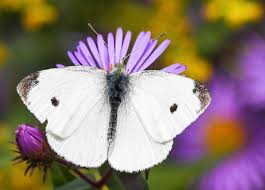

and "pine white":

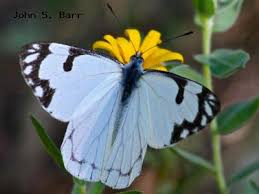

we can notice quite a few similarities - their shape, the fact most of their color is white, and that both have some sort of symmetric black/brown pattern on their wings. Same goes for species with the second word of their name being "streak" being clustered together in the green cluster and those with "eggfly" in the orange cluster.
*   Another thing we can notice is the smallest distance between two species - "large marble" and "eastern dapple white":

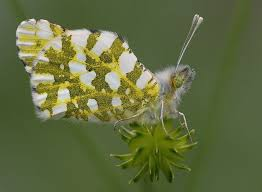


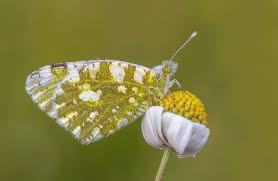

The interesting thing, except for their obvious physical resemblance, that their scientific names are "Euchloe ausonides" & "Euchloe ausonia". Meaning both belong to the same genus of butterflies. For this genus (and others deriving from the same tribe), the american species are usually called marbles, and the ones from europe are called dappled whites.

So, by looking at this hierarchical clustering we can notice it clustered correctly by physical traits, but also managed to cluster species of the same tribe together, thus making sense biologically!

## K-Means Clustering:

K-means is an algorithm that clusters data points into a pre-determined number, k, of groups. This algorithm is unsupervised, meaning it find patterns with no prior classification knowledge.

We'll group classes into k clusters and visualize the clusters with colors on a scatter plot.

First we want to find the smallest number of components, capturing at least 95% of the variance

In [ ]:
pca_full = PCA().fit(class_avg_vecs)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f'Using {n_components_95} PCA components to capture at least 95% variance')

Then we reduce to the chosen number of components

In [ ]:
pca = PCA(n_components=n_components_95)
avg_reduced = pca.fit_transform(class_avg_vecs)

Reducing to 2D for plotting nicely:

In [ ]:
avg_2d = PCA(n_components=2).fit_transform(avg_reduced)

Now, we want to find the number of clusters. We will use the **Elbow Method**.

The Elbow Method is used frequently in order to find the number of clusters for a dataset. It consists of calculating the inertia for a range of k values. The inertia is the sum of squared distances between each data point and its assigned cluster centroid. When plotted against the number of clusters, we'll be able to see an "elbow" point in the plot, where the rate of decrease in the inertia changes drastically, it slows down and the curve starts to flatten. It is said this point suggests an optimal number of clusters.

In [ ]:
wcss = []
for i in range(1, 31):
  kmeans = KMeans(n_clusters=i, random_state=0)
  kmeans.fit(avg_reduced)
  wcss.append(kmeans.inertia_)

plt.plot(range(1, 31), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

By looking at the graph above we can tell the main point where the interia changes and the curve starts to flatten more is around 16, so according to that we'll set k=16 for the k-means clustering.

In [ ]:
k = 16
kmeans = KMeans(n_clusters=k, random_state=0)
clusters = kmeans.fit_predict(avg_reduced)

And lastly we'll plot the clusters:

In [ ]:
!pip install adjustText -q

In [ ]:
from adjustText import adjust_text

plt.figure(figsize=(12, 8))
plt.scatter(avg_2d[:,0], avg_2d[:,1], c=clusters, cmap="tab10", s=80, alpha=0.7)

texts = []
for i, label in enumerate(class_labels):
  texts.append(plt.text(avg_2d[i,0], avg_2d[i,1], label, fontsize=6))

adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

plt.title("K-Means Clustering of class averages")
plt.show()

This plot is a bit confusing and all over the place, so here's a breakdown:



*   Each dot represents a class, corresponding to the title above it.
*   The X and Y axes don't correspond directly to the images, but they represent directions of variance in the data, since we reduced the data into two components using PCA.
*   Classes closer to eachother in the plot correspond to higher average image similarity.
*   Different classes are grouped in the same cluster if they share the same color. The groups are chosen by the K-Means, based on similarity in the pixel space.

As we can notice many orange-labeled classes are close to eachother and so are the greens, meaning K-Means thinks their average images look similar. Contrary to that, the blue-labeled classes are not quite grouped together

Furthermore, some clusters (orange, cyan and gray) are very compact, which means K-Means thought they have lots of visually similar features. The green cluster, for example, is less dense and compact, meaning it's less cohesive and noticabely similar to K-Means.


# **Prediction Models**

In this chapter we are going to train and test different models (different structures, pretrained and trained ourselves) on either the butterfly images themselves (for Convolutional Networks) or the feature vectors that have went through dimensionality reduce using PCA.

We start off with simpler models, such as SVM and a simple neaural network from scratch, then we use intricate models such as a CNN, a model takem from Hugging Face, and two usages of CLIP.

At last, we compare all of their results, which classes each of them had a tough time classificating and explain with our understanding why that was the case.

## **Simpler Models**

In this section we train models on the results of the features extracted by CLIP, that went through PCA for dimnesionality reduction.

These models are often considered "simple" due to either having a small structure (i.e. not many layers/neurons per layer), or meant to be applied for simpler jobs.

We are checking these first because we want to find out how well they can perform, when being given the extracted features vector as an input, instead of the images/pixels themselves. After we execute everything, we will compare the results of all models

### Baseline: SVM on PCA
Let's train our first model. We want something simple, fast, and well-understood to use as a baseline, so we chose a linear SVM. This gives us a clean reference point: if our fancy models later on can't beat this, something is probably wrong. We don’t expect this baseline to capture all the visual complexity of butterflies, but it should give us a reasonable first sense of how hard the task is and what kind of accuracy we can aim to improve on.


In [ ]:
X_train_scaled = results_clip['train_scaled']
X_test_scaled = results_clip['test_scaled']
y_train = results_clip['y_train']
y_test = results_clip['y_test']

In [ ]:
# Train classifier
clf = SGDClassifier(loss="hinge", alpha=1e-4, random_state=RANDOM_STATE,
                    max_iter=500, tol=1e-3)
clf.fit(X_train_scaled, y_train)

# Predictions
y_pred = clf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"[SVM] Test accuracy: {acc:.4f}")

report = classification_report(
    y_test, y_pred, target_names=class_names, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report).transpose()
print("\nClassification Report:\n")
print(report_df.round(3))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

def abbr(s, maxlen=14):
    s = s.replace("-", " ")
    out = " ".join(w[:10] for w in s.split())
    return out[:maxlen]
short_names = [abbr(s) for s in class_names]

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=short_names, yticklabels=short_names)
plt.title("Confusion Matrix (counts)"); plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(rotation=90, fontsize=7); plt.yticks(fontsize=7)
plt.tight_layout(); plt.show()

cols = ["precision", "recall", "f1-score"]
per_class = report_df.iloc[:-1][cols].copy()
per_class = report_df.iloc[:-1][["precision", "recall", "f1-score"]].copy()
per_class["name"] = per_class.index
top = per_class.sort_values("f1-score", ascending=False).head(20).set_index("name")
ax = top.plot(kind="bar", figsize=(12, 6))
plt.title("Top-20 classes by F1")
plt.ylabel("Score"); plt.ylim(0, 1)
plt.xticks(rotation=90, fontsize=8)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


This simple model has achieved an ~84% accuracy! We have printed the classification report and plotted a confusion matrix in order to examine the performance of this model. Let's take a look:

As we can tell by both the confusion matrix, and the top 20 classes graph, the model did a generally good job for such a simple model, showcasing the importance of the feature extraction.

If we take a further look at the confusion matrix, we can notice the darkest ractangle outside of the main diagonal appears to be predictions of the "Question Mark" species when being given inputs of the "Eastern Comma" species.

When searching online, we came accross the same realization we had earlier when viewing two other species that were clustered together - these two butterfly species share, aside from their unusual names containing punctuation marks, a family and the ability to camouflage themselves using the color and texture of their wings. Here are images of the "Question Mark" and "Eastern Comma" species, respectively:

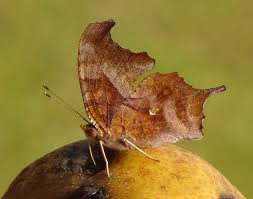

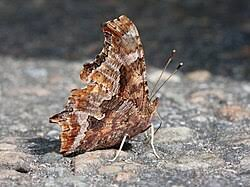

As we can see in the images, not only are their colors similar but also their entire wing structure!

Aside from the butterflies that got confused with other species, we have species such as "Adonis" which didn't get confused even once - no other species was predicted as Adonis nor was Adonis predicted for others. Let's take a look at the "Adonis" species:

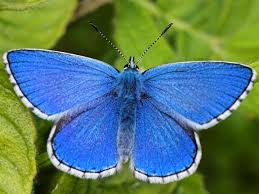

### Neural network: a non-linear baseline
After the linear SVM, we wanted to see whether a simple neural network could squeeze more information out of the same features. We use a small fully connected MLP with two hidden layers and ReLU activations, trained with Adam and early stopping so we don’t just overfit the training set. This model can capture non-linear relationships between features that a linear classifier can’t, while still staying relatively compact and fast to train.


In [ ]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(SimpleMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

# Create training dataset and DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# create model
model = SimpleMLP(input_dim=X_train_scaled.shape[1], num_classes=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=3e-4)

# train the model
best_acc = 0
patience, patience_counter = 50, 0

for epoch in range(100):
    model.train()
    total_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/100", leave=False)
    for xb, yb in loop:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        # Update tqdm postfix
        loop.set_postfix(loss=loss.item())

    # Validation accuracy
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            predicted = preds.argmax(dim=1)
            correct += (predicted == yb).sum().item()
            total += yb.size(0)
    acc = correct / total

    # Early stopping
    if acc > best_acc:
        best_acc = acc
        patience_counter = 0
        best_state = model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            break

# Load best model
model.load_state_dict(best_state)

# evaluation
model.eval()
y_pred_nn = []

with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        preds = model(xb)
        y_pred_nn.extend(preds.argmax(dim=1).cpu().numpy())

# accuracy
acc_nn = accuracy_score(y_test, y_pred_nn)
print(f"[NN] Test accuracy: {acc_nn:.4f}")

report_nn = classification_report(
    y_test, y_pred_nn, target_names=class_names, output_dict=True
)
report_df_nn = pd.DataFrame(report_nn).transpose()
print("\nClassification Report (Neural Network):\n")
print(report_df_nn.round(3))

cm_nn = confusion_matrix(y_test, y_pred_nn)

short_names_nn = [abbr(s) for s in class_names]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_nn, annot=False, cmap="Blues",
            xticklabels=short_names_nn,
            yticklabels=short_names_nn)
plt.title("Confusion Matrix (Neural Network)", fontsize=16)
plt.xlabel("Predicted", fontsize=14)
plt.ylabel("True", fontsize=14)
plt.xticks(rotation=90, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


# --- Per-class metrics (NN) ---
cols = ["precision", "recall", "f1-score"]
per_class_nn = report_df_nn.iloc[:-1][cols].copy()
per_class_nn["name"] = per_class_nn.index

# Take Top-20 by F1
top_nn = per_class_nn.sort_values("f1-score", ascending=False).head(20).set_index("name")

ax = top_nn.plot(kind="bar", figsize=(14, 8), colormap="viridis")
plt.title("Top-20 Classes by F1 (Neural Network)", fontsize=16)
plt.ylabel("Score", fontsize=14)
plt.ylim(0, 1)
plt.xticks(rotation=90, ha="right", fontsize=10)
plt.legend(loc="lower right", fontsize=12)
plt.tight_layout()
plt.show()


This model has achieved an accuracy of ~88%, meaning it's a bit more precise than the former model, but has experienced an early stop, probably due to achieving a very high percentage of accuracy during the val process for each epoch in the training, wanting the model not to overfit.

Let's take a look at some of the performance detailed printed out for us:

Looking at the confusion matrix we notice that the darkest rectangle was again wrong predictions for the "Eastern Comma" species. Like the former model, those predictions were the "Question Mark" species. Meaning, both simple models had failed to distinguish between these two species.

This model did not predict perfectly for the "Adonis" species unlike the former one. However, there are 17 species out of the 75 which were perfectly guessed by this model (same as Adonis was for the former), surpassing the former one with only 10!

And lastly, the model did an overall good job, having most of the prediction be precise (as we can see by the darkness of the main diagonal in the confusion matrix).

## **Advanced Models**

from this point on we'll train on the images so we won't be able to use the PCA-produced data, we'll define:

In [ ]:
X = []
y = []

for img_flat, label_idx, _, _ in tqdm(pixel_ds):
  X.append(img_flat)
  y.append(label_idx)

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train_img = X_train.reshape(-1, H, W, 3).astype(np.float32)
X_test_img  = X_test.reshape(-1, H, W, 3).astype(np.float32)

Now, having defined the training and testing data, we can continue to the construction of the Convolutional Network, training and testing:

### Convolutional Neural Network (CNN)

In this step, we switch to a model that is designed specifically for image data. A CNN is well-suited for this task because it can learn visual patterns directly from the butterfly images, such as shapes, textures, and color structures.

This is different from the previous methods we used, where we first had to extract features (PCA, HOG, DINOv2) and only then train a classifier. With a CNN, the feature extraction and the classification happen together inside one model.

Here, we train a CNN from scratch on the raw images to see how well it can learn the butterfly species without any manual feature engineering.

### CNN Architecture

We use a simple and lightweight CNN that fits our dataset size. It has three convolutional layers:
- 3→32 channels  
- 32→64 channels  
- 64→128 channels  

Each uses a 3×3 kernel, ReLU activation, and a max-pool step to gradually reduce the spatial size.
After the convolutions, an adaptive average pooling layer forces the output to 8×8, keeping the classifier shape consistent.

The classifier head is straightforward:
- flatten  
- linear layer to 256 units  
- ReLU + dropout  
- final linear layer to the number of butterfly classes

We train the whole network from scratch using Adam and cross-entropy loss. This gives us a direct comparison point to the feature-based methods earlier in the project.


In [ ]:
assert X_train_img.ndim == 4 and X_train_img.shape[-1] == 3, "X_train_img must be (N,H,W,3)"
assert X_test_img.ndim  == 4 and X_test_img.shape[-1]  == 3, "X_test_img must be (N,H,W,3)"
H, W = X_train_img.shape[1], X_train_img.shape[2]

if X_train_img.dtype != np.float32: X_train_img = X_train_img.astype(np.float32, copy=False)
if X_test_img.dtype  != np.float32: X_test_img  = X_test_img.astype(np.float32, copy=False)

if np.nanmax(X_train_img) > 1.0 or np.nanmax(X_test_img) > 1.0:
    X_train_img = X_train_img / 255.0
    X_test_img  = X_test_img  / 255.0

X_train_t = torch.from_numpy(np.transpose(X_train_img, (0, 3, 1, 2))).float()
X_test_t  = torch.from_numpy(np.transpose(X_test_img,  (0, 3, 1, 2))).float()
y_train_t = torch.from_numpy(y_train).long()
y_test_t  = torch.from_numpy(y_test).long()

X_train_t = (X_train_t - 0.5) / 0.5
X_test_t  = (X_test_t  - 0.5) / 0.5

val_frac = (VAL_SIZE if "VAL_SIZE" in globals() else 0.1)  # default 10% val
val_size = max(1, int(val_frac * len(X_train_t)))
train_size = len(X_train_t) - val_size

g = torch.Generator().manual_seed(RANDOM_STATE) if "RANDOM_STATE" in globals() else None
full_train_ds = TensorDataset(X_train_t, y_train_t)
train_ds, val_ds = random_split(full_train_ds, [train_size, val_size], generator=g)

use_cuda = torch.cuda.is_available()
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2, pin_memory=use_cuda)
val_loader   = DataLoader(val_ds,   batch_size=128, shuffle=False, num_workers=2, pin_memory=use_cuda)

test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=128, shuffle=False,
                          num_workers=2, pin_memory=use_cuda)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),   # H,W -> /2
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),   # -> /4
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),   # -> /8
            nn.AdaptiveAvgPool2d((8, 8))  # ensure 8x8 regardless of input size
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

num_classes = len(class_names) if "class_names" in globals() else int(y_train_t.max().item() + 1)

device = "cuda" if use_cuda else "cpu"
model = SimpleCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 20
for epoch in range(EPOCHS):
    # train model
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)

    # validate
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model(imgs)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / max(1, total)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {running_loss/len(train_ds):.4f} | Val Acc: {val_acc:.4f}")

# evaluation
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device, non_blocking=True)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())

y_pred_cnn = np.concatenate(all_preds)
y_true_cnn = np.concatenate(all_labels)

# accuracy
acc_cnn = accuracy_score(y_true_cnn, y_pred_cnn)
print(f"[CNN] Test accuracy: {acc_cnn:.4f}")

report_cnn = classification_report(
    y_true_cnn, y_pred_cnn, target_names=class_names, output_dict=True
)
report_df_cnn = pd.DataFrame(report_cnn).transpose()
print("\nClassification Report (CNN):\n")
print(report_df_cnn.round(3))

# confusion matrix
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

short_names_cnn = [abbr(s) for s in class_names]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_cnn, annot=False, cmap="Blues",
            xticklabels=short_names_cnn, yticklabels=short_names_cnn)
plt.title("Confusion Matrix (CNN)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(rotation=90, fontsize=7); plt.yticks(fontsize=7)
plt.tight_layout(); plt.show()

# ---- Metrics per Class (CNN) ----
cols = ["precision", "recall", "f1-score"]
per_class_cnn = report_df_cnn.iloc[:-1][cols].copy()
per_class_cnn["name"] = per_class_cnn.index

top_cnn = per_class_cnn.sort_values("f1-score", ascending=False).head(20).set_index("name")
ax = top_cnn.plot(kind="bar", figsize=(12, 6), colormap="plasma")
plt.title("Top-20 Classes by F1 (CNN)")
plt.ylabel("Score"); plt.ylim(0, 1)
plt.xticks(rotation=90, fontsize=8)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

As we can see, the Convolutional Neural Network model did not perform quite well, achieving a low accuracy of ~59% accuracy.

For starters, let's look at the loss and validation accuracy per epoch:


*   The training loss keeps decreasing in a steady manner, meaning the model is learning.
*   The validation accuracy initially rises but then remains at around 61-63%.
*   The test accuracy is 59.2%, which is quite close to the percentage the validation accuracy was flatten at.

From all of these we can presume an overfitting has not occurred, since the validation accuracy wasn't dropping but rather flattening. Conversely, the model could be **underfitting** - the loss is still decreasing as the validation accuracy is flattening, the model may not have enough capacity to fully capture all the patterns. Lastly, the fact that the validation and test accuracies are close indicates the generalization of the model is stable (which makes sense to us since this is a pretrained model which is commonly used for these zero-shot types of tasks).



### Understanding the process of the CNN

Neural networks can be hard to interpret because we don’t always know *why* they predict a certain class.  
Grad-CAM (Gradient-weighted Class Activation Mapping) gives us a way to “look inside” the CNN.  
It highlights the regions of an input image that most strongly influenced the model’s decision.  
By overlaying these heatmaps on butterfly images, we can see which visual features the network focuses on.


In [ ]:
# Get the last conv layer
def get_last_conv_layer(net: nn.Module):
    for m in reversed(list(net.features)):
        if isinstance(m, nn.Conv2d):
            return m
    raise RuntimeError("No Conv2d layer found in model.features")

LAST_CONV = get_last_conv_layer(model)

# Preprocess helper
def preprocess_np_img(img_np: np.ndarray, device: str):
    t = torch.from_numpy(img_np.transpose(2,0,1)).float()
    t = (t - 0.5) / 0.5
    return t.unsqueeze(0).to(device)

# Grad-CAM for one image
def gradcam_single(model, x_in: torch.Tensor, target_layer: nn.Module, target_class=None):
    model.eval()
    feats, grads = [], []

    def f_hook(_m, _i, o): feats.append(o)
    def b_hook(_m, gi, go): grads.append(go[0])

    h_f = target_layer.register_forward_hook(f_hook)
    try:
        h_b = target_layer.register_full_backward_hook(b_hook)
    except AttributeError:
        h_b = target_layer.register_backward_hook(b_hook)

    logits = model(x_in)
    if target_class is None:
        target_class = int(logits.argmax(dim=1).item())
    loss = logits[0, target_class]

    model.zero_grad(set_to_none=True)
    loss.backward()

    A, dA = feats[0], grads[0]
    weights = dA.mean(dim=(2,3), keepdim=True)
    cam = (weights * A).sum(dim=1).squeeze()
    cam = torch.relu(cam)
    cam = cam / (cam.max() + 1e-8)
    cam_np = cam.detach().cpu().numpy()

    h_f.remove(); h_b.remove()
    return cam_np, target_class

# Show heatmap overlay inline
def show_gradcam_overlay(cam_np, img_np, title=""):
    H, W = img_np.shape[:2]
    cam_t = torch.from_numpy(cam_np)[None, None].float()
    cam_up = F.interpolate(cam_t, size=(H,W), mode="bilinear", align_corners=False).squeeze().numpy()

    plt.figure(figsize=(4,4))
    plt.imshow(img_np)
    plt.imshow(cam_up, cmap="jet", alpha=0.4)
    plt.axis("off")
    if title: plt.title(title)
    plt.show()

# Run on a test image
idx = 0
img_np = X_test_img[idx]
x_in = preprocess_np_img(img_np, device)

cam_np, c_idx = gradcam_single(model, x_in, LAST_CONV)
cls_name = class_names[c_idx] if "class_names" in globals() else str(c_idx)

show_gradcam_overlay(cam_np, img_np, title=f"Grad-CAM: {cls_name}")


By looking at the grad cam above, we can see the CNN model had predicted mostly based on a specific part of the wings. Let's look at a random picture of the "AN 88" class and see if there is any specific feature at that spot:

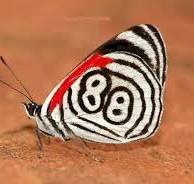

As we can see, the name of this species was uniquely chosen based on the pattern on its wings, appearing as two 8s next to each other, or the number 88.
Since this is a specific feature for this butterfly species, it makes sense that the CNN model would focus on it.
But, althought the model understood how to single out a feature that is unique for this species, it still didn't have a perfect presicion. We can see that the model guessed "AN 88" on a few "Monarch" images. Let's take a look at the monarch butterfly species:

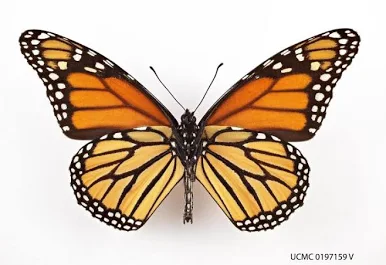

We can see where the confusion might have come from - the Monarch butterfly has lines crossing on its wings, almost appearing as the digit 8. This confusion could entail that the model looked less at the colors of the butterflies (because we can clearly see their colors aren't very similar).

### Pretrained model from **Hugging Face**
We will be following the process for image classification (zero-shot) using the "pipeline" command, as can be seen in the learning guide at chapter 10.2. This process utilizes aa pretrained model, which is intended to be used for image classification on datasets it hasn't necessarily seen already, given the classification options. This model was pre-trained on a large set of images, and fine-tuned on the ImageNet dataset, containing a million images and 1,000 classes.

In addition, this image is Google's version of OpenAI's CLIP, with a different loss function.

In [ ]:
!pip install timm -q
!pip install sentencepiece
!pip install protobuf

In [ ]:
from transformers import pipeline
classifier = pipeline("zero-shot-image-classification", model="google/siglip-base-patch16-224")

In [ ]:
to_pil = transforms.ToPILImage()

# evaluation
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device, non_blocking=True)
        for img, label in zip(imgs, labels):
            # img is a tensor, convert to PIL
            img_pil = to_pil(img.cpu())  # move to CPU first
            output = classifier(image=img_pil, candidate_labels=class_names)
            pred_label = output[0]['label']
            all_preds.append(pred_label)
            all_labels.append(label.numpy())

print(len(all_preds), len(all_labels))
y_pred_hf = np.array(all_preds)
y_true_hf = np.array(all_labels)
y_true_hf = [class_names[i] for i in y_true_hf]
print(len(y_pred_hf), len(y_true_hf))

# accuracy
acc_hf = accuracy_score(y_true_hf, y_pred_hf)
print(f"[HF] Test accuracy: {acc_hf:.4f}")

report_hf = classification_report(
    y_true_hf, y_pred_hf, target_names=class_names, output_dict=True
)
report_df_hf = pd.DataFrame(report_hf).transpose()
print("\nClassification Report (HF):\n")
print(report_df_hf.round(3))

# confusion matrix
cm_hf = confusion_matrix(y_true_hf, y_pred_hf)

short_names_hf = [abbr(s) for s in class_names]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_hf, annot=False, cmap="Blues",
            xticklabels=short_names_hf, yticklabels=short_names_hf)
plt.title("Confusion Matrix (HF)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(rotation=90, fontsize=7); plt.yticks(fontsize=7)
plt.tight_layout(); plt.show()

# ---- Metrics per Class (HF) ----
cols = ["precision", "recall", "f1-score"]
per_class_hf = report_df_hf.iloc[:-1][cols].copy()
per_class_hf["name"] = per_class_hf.index

top_hf = per_class_hf.sort_values("f1-score", ascending=False).head(20).set_index("name")
ax = top_hf.plot(kind="bar", figsize=(12, 6), colormap="plasma")
plt.title("Top-20 Classes by F1 (HF)")
plt.ylabel("Score"); plt.ylim(0, 1)
plt.xticks(rotation=90, fontsize=8)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

This model had the worst performace so far by a large margin, arriving at 7.54% accuracy. As we can see, its performance is quite all over the place, having predicted some classes over and over again, whilst some classes were not predicted even once! There seem to be a few classes the model randomly kept guessing though.

Since this model was brought from Hugging Face, with never seeing this specific dataset before, it makes sense that the results are low. Especially if this kind of model has no experience in viewing butterfly images.

Overall, the prediction seem random, there doesn't seem to be a certain pattern going on in the confusion matrix above.

By the F1-score plot we can see there are some classes it predicted correctly when it guessed, but lacked a few predictions, and some classes are the opposite with the predictions being mistakes, but also predicting correctly when the class was the true label.

### **Using CLIP**

#### CLIP (Frozen) — Embeddings + Simple Head

We extract **frozen CLIP embeddings** for all images, then reuse the same simple heads as above (**SVM and/or MLP**) on top of those embeddings.

**Steps:**  
1) Embed train/test with CLIP (no tuning).  
2) Train a head on train embeddings.  
3) Evaluate on test (accuracy + macro-F1).

**Expectation:** should beat PCA baselines due to stronger features.


In [ ]:
# classic models on frozen clip
def make_models() -> Dict[str, object]:
    return {
        "LinearSVM": LinearSVC(C=1.0, random_state=RANDOM_STATE),
        "KNN": KNeighborsClassifier(n_neighbors=5, metric="cosine", weights="distance", n_jobs=-1),
        "LogReg": LogisticRegression(multi_class="multinomial", solver="saga",
                                     max_iter=1000, n_jobs=-1, random_state=RANDOM_STATE),
    }

def evaluate_models(X_train, y_train, X_test, y_test):
    cv = StratifiedKFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=RANDOM_STATE)
    models = make_models(); rows, preds = [], {}
    for name, model in models.items():
        t0 = time.perf_counter()
        cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test); preds[name] = y_pred
        rows.append({
            "model": name,
            "cv_acc_mean": float(np.mean(cv_scores)),
            "cv_acc_std": float(np.std(cv_scores)),
            "test_acc": accuracy_score(y_test, y_pred),
            "test_macro_f1": f1_score(y_test, y_pred, average="macro"),
            "train_secs": time.perf_counter() - t0
        })
    df = pd.DataFrame(rows).sort_values("test_acc", ascending=False).reset_index(drop=True)
    return df, models, preds

results_frozen, frozen_models, frozen_preds = evaluate_models(emb_trval, y_trval, emb_test, y_test_enc)
print("\n=== classic models on frozen clip embeddings ===")
print(results_frozen)

# visuals
def report_df(y_true, y_pred, class_names):
    rep = classification_report(
        y_true, y_pred, labels=list(range(len(class_names))),
        target_names=class_names, output_dict=True, zero_division=0
    )
    return pd.DataFrame(rep).T

def plot_cm(cm, classes, title):
    short = [abbr(s) for s in classes]
    plt.figure(figsize=(12,10))
    sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=short, yticklabels=short)
    plt.title(title); plt.xlabel("predicted"); plt.ylabel("true")
    plt.xticks(rotation=90, fontsize=7); plt.yticks(fontsize=7)
    plt.tight_layout(); savefig(f"{title}.png"); plt.show()

def plot_top20_f1(df, title):
    cols = ["precision", "recall", "f1-score"]
    per_class = df.iloc[:-1][cols].copy(); per_class["name"] = per_class.index
    top = per_class.sort_values("f1-score", ascending=False).head(20).set_index("name")
    ax = top.plot(kind="bar", figsize=(12,6))
    plt.title(title); plt.ylabel("score"); plt.ylim(0,1)
    plt.xticks(rotation=90, fontsize=8)
    plt.legend(loc="lower right"); plt.tight_layout(); savefig(f"{title}.png"); plt.show()

best_frozen_name = results_frozen.iloc[0]["model"]
y_pred_frozen = frozen_preds[best_frozen_name]
cm_frozen = confusion_matrix(y_test_enc, y_pred_frozen, labels=list(range(len(class_names))))
rep_frozen = report_df(y_test_enc, y_pred_frozen, class_names)

plot_cm(cm_frozen, class_names, title=f"frozen→{best_frozen_name} (counts)")
plot_top20_f1(rep_frozen, title="frozen: top-20 classes by f1")


#### CLIP (Fine-Tuned) — Re-embed and Re-train

We **fine-tune CLIP** on the train set, then **re-embed** images and **re-train the same head(s)** for a fair comparison.

**Steps:**  
1) Fine-tune CLIP on train.  
2) Recompute embeddings (train/test).  
3) Re-train SVM/MLP head on train embeddings.  
4) Evaluate on test; compare vs. frozen.

**Goal:** improved **macro-F1**, especially for visually similar species.


In [ ]:
class CLIPWithHead(nn.Module):
    def __init__(self, base_model: nn.Module, num_classes: int):
        super().__init__()
        self.base = base_model
        emb_dim = getattr(self.base, "embed_dim", getattr(self.base.visual, "output_dim"))
        self.head = nn.Linear(emb_dim, num_classes)
    def forward(self, images):
        feats = self.base.encode_image(images)
        feats = feats / feats.norm(dim=1, keepdim=True).clamp(min=1e-12)
        return self.head(feats), feats

def set_trainable_params(model, mode="last_k", last_k=UNFREEZE_LAST_BLOCKS):
    for p in model.base.parameters(): p.requires_grad = False
    for p in model.head.parameters(): p.requires_grad = True
    if mode == "full":
        for p in model.base.parameters(): p.requires_grad = True
        return
    vis = model.base.visual
    if hasattr(vis, "transformer") and hasattr(vis.transformer, "resblocks"):
        for blk in vis.transformer.resblocks[-last_k:]:
            for p in blk.parameters(): p.requires_grad = True
        if hasattr(vis, "ln_post"):
            for p in vis.ln_post.parameters(): p.requires_grad = True
        if hasattr(vis, "proj") and isinstance(getattr(vis, "proj"), torch.nn.Parameter):
            vis.proj.requires_grad = True
    if hasattr(vis, "layer4"):
        for p in vis.layer4.parameters(): p.requires_grad = True

def make_optimizer(model, head_lr=None, base_lr=None, weight_decay=WEIGHT_DECAY):
    head_lr = head_lr or (LR * 5.0)
    base_lr = base_lr or LR
    head_params = [p for p in model.head.parameters() if p.requires_grad]
    base_params = [p for p in model.base.parameters() if p.requires_grad]
    groups = []
    if head_params: groups.append({"params": head_params, "lr": head_lr})
    if base_params: groups.append({"params": base_params, "lr": base_lr})
    return optim.AdamW(groups, weight_decay=weight_decay)

def run_finetune(model, device, train_loader, val_loader, epochs=EPOCHS,
                 label_smoothing=LABEL_SMOOTHING, early_stop=EARLY_STOP_PATIENCE, amp=AMP):
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = make_optimizer(model)
    total_steps = len(train_loader) * epochs
    sched = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=[pg["lr"] for pg in optimizer.param_groups],
        total_steps=total_steps, pct_start=0.1
    )
    scaler = torch.cuda.amp.GradScaler(enabled=amp)
    best_state, best_val, patience = None, -1.0, 0

    try:
        model = torch.compile(model)  # pytorch 2.x
    except Exception:
        pass

    for epoch in range(epochs):
        model.train(); correct = total = 0
        for x, y, *_ in dl_train:
            x, y = x.to(device, non_blocking=pin), y.to(device, non_blocking=pin)
            optimizer.zero_grad(set_to_none=True)
            ctx = torch.autocast(device_type="cuda", enabled=amp)
            with ctx:
                logits, _ = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update()
            sched.step()
            correct += (logits.argmax(1) == y).sum().item(); total += y.size(0)
        train_acc = correct / max(1,total)

        model.eval(); correct = total = 0
        with torch.inference_mode():
            for x, y, *_ in dl_val:
                x, y = x.to(device, non_blocking=pin), y.to(device, non_blocking=pin)
                ctx = torch.autocast(device_type="cuda", enabled=amp)
                with ctx:
                    logits, _ = model(x)
                correct += (logits.argmax(1) == y).sum().item(); total += y.size(0)
        val_acc = correct / max(1,total)
        print(f"epoch {epoch+1}: train_acc={train_acc:.4f} val_acc={val_acc:.4f}")

        if val_acc > best_val:
            best_val, best_state, patience = val_acc, copy.deepcopy(model.state_dict()), 0
        else:
            patience += 1
            if patience >= early_stop:
                print("early stop"); break

    if best_state is not None: model.load_state_dict(best_state)
    return model

num_classes = len(class_names)
model_ft = CLIPWithHead(base_model, num_classes).to(device)
set_trainable_params(model_ft, mode="last_k", last_k=UNFREEZE_LAST_BLOCKS)

print("\n=== fine-tuning clip ===")
model_ft = run_finetune(model_ft, device, dl_train, dl_val)


In [ ]:
emb_trval_ft, lab_trval_ft = extract_embeddings(dl_trval, model_ft.base, device)
emb_test_ft,  lab_test_ft  = extract_embeddings(dl_test,   model_ft.base, device)
y_trval_ft = le.transform(lab_trval_ft)
y_test_enc_ft = le.transform(lab_test_ft)

results_ft, ft_models, ft_preds = evaluate_models(emb_trval_ft, y_trval_ft, emb_test_ft, y_test_enc_ft)
print("\n=== classic models on fine-tuned clip embeddings ===")
print(results_ft)

best_ft_name = results_ft.iloc[0]["model"]
y_pred_ft = ft_preds[best_ft_name]
cm_ft = confusion_matrix(y_test_enc_ft, y_pred_ft, labels=list(range(len(class_names))))
rep_ft = report_df(y_test_enc_ft, y_pred_ft, class_names)

plot_cm(cm_ft, class_names, title=f"finetuned→{best_ft_name} (counts)")
plot_top20_f1(rep_ft, title="finetuned: top-20 classes by f1")


let's compare the results

In [ ]:
# compare table
frozen_tbl = results_frozen.copy(); frozen_tbl["stage"] = "frozen"
ft_tbl = results_ft.copy(); ft_tbl["stage"] = "finetuned"
compare_df = pd.concat([frozen_tbl, ft_tbl], axis=0, ignore_index=True)
print(compare_df.sort_values(["model","stage"]).reset_index(drop=True))

# normalized cms
def normalize_cm(cm):
    with np.errstate(divide="ignore", invalid="ignore"):
        rs = cm.sum(axis=1, keepdims=True)
        return np.divide(cm, rs, where=rs!=0)

plot_cm((normalize_cm(cm_frozen)*100).round(1), class_names, title=f"frozen→{best_frozen_name} (row-% )")
plot_cm((normalize_cm(cm_ft)*100).round(1),     class_names, title=f"finetuned→{best_ft_name} (row-% )")

# stage comparison bars
def stage_bar(df, metric="test_acc"):
    pv = df.pivot_table(index="model", columns="stage", values=metric)
    ax = pv.plot(kind="bar", figsize=(11,6))
    plt.title(f"frozen vs finetuned: {metric}")
    plt.ylabel(metric);
    if metric != "train_secs": plt.ylim(0,1)
    plt.xticks(rotation=0); plt.tight_layout(); savefig(f"compare_{metric}.png"); plt.show()

stage_bar(compare_df, "test_acc")
stage_bar(compare_df, "test_macro_f1")

# delta confusion: where did errors shift?
delta_cm = cm_ft - cm_frozen
plt.figure(figsize=(12,10))
sns.heatmap(delta_cm, cmap="coolwarm", center=0,
            xticklabels=[abbr(s) for s in class_names],
            yticklabels=[abbr(s) for s in class_names])
plt.title("delta confusion (finetuned − frozen)")
plt.xlabel("predicted"); plt.ylabel("true")
plt.xticks(rotation=90, fontsize=7); plt.yticks(fontsize=7)
plt.tight_layout(); savefig("delta_confusion.png"); plt.show()

# geometry change: pca overlay (same components)
pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(np.vstack([emb_test, emb_test_ft]))
Z_frozen = pca.transform(emb_test); Z_ft = pca.transform(emb_test_ft)

plt.figure(figsize=(10,4.5))
plt.subplot(1,2,1)
plt.scatter(Z_frozen[:,0], Z_frozen[:,1], c=y_test_enc, s=8, alpha=0.7, cmap="tab20")
plt.title("pca: frozen"); plt.xticks([]); plt.yticks([])
plt.subplot(1,2,2)
plt.scatter(Z_ft[:,0], Z_ft[:,1], c=y_test_enc_ft, s=8, alpha=0.7, cmap="tab20")
plt.title("pca: finetuned"); plt.xticks([]); plt.yticks([])
plt.tight_layout(); savefig("pca_frozen_vs_ft.png"); plt.show()

# “hard classes”: which labels gained most f1?
def per_class_f1(df):
    sub = df.iloc[:-1][["precision","recall","f1-score"]].copy()
    sub["name"] = sub.index; return sub

pc_frozen = per_class_f1(rep_frozen).set_index("name")
pc_ft     = per_class_f1(rep_ft).set_index("name")
delta_f1  = (pc_ft["f1-score"] - pc_frozen["f1-score"]).sort_values(ascending=False)

plt.figure(figsize=(12,6))
delta_f1.head(15).plot(kind="bar")
plt.title("biggest f1 gains after fine-tuning (top-15)")
plt.ylabel("Δf1"); plt.ylim(min(0, delta_f1.head(15).min()-0.02), 1.0)
plt.xticks(rotation=90, fontsize=8); plt.tight_layout(); savefig("delta_f1_top15.png"); plt.show()

plt.figure(figsize=(12,6))
delta_f1.tail(15).plot(kind="bar")
plt.title("classes that got worse after fine-tuning (bottom-15)")
plt.ylabel("Δf1"); plt.xticks(rotation=90, fontsize=8)
plt.tight_layout(); savefig("delta_f1_bottom15.png"); plt.show()


# Discussion & Takeaways

We'll preface this by stating that we did not expect both of the simpler models (SVM and Neural Network) to perform better and have a higher precision percentage than the Convolutional network, but this might have been the case due to not feeding them the raw data as input but rather extracted features, unlike the raw images that the CNN received.

## Why the SVM (baseline) did much better than expected but still not amazing
**84% Accuracy**

The model becomes good only after we hand it a feature extractor that already encodes some of the visual understanding.
- **Linear Separability Limitation:** SVMs work best when classes are roughly linearly separable in the feature space. If the extracted features are non-linearly related, the SVM model might struggle to capture complex decision boundaries.
- **Scaling/Normalization issues:** SVMs are very sensitive to feature scales. If the feature vector wasn't carefully normalized or standardized, the performance of the model can degrade.
- **Stable Training:** Unlike MLPs, SVMs converge to a global optimum for convex problems, so results are less dependant on random initialization or optimization quirks.
- **Robust CLassifier:** SVMs are a strong classical baseline models, particularly for small-medium sized datasets. Achieving around 84% accuracy indicates that the extracted features are meaningful and that a linear or moderately nonlinear decision boundary can capture much of the structure.

## Why the MLP did slightly better than the SVM
**~88.31% Accuracy**
- **Better Interpretability:** Because features are engineered, they might have semantic meaning, making it easier to interpret what the model is basing its decisions on.
- **Overfitting tendencies:** Because the feature space is already engineered, the MLP might overfit on that space rather than learning more generalizable patterns.
- **Augmentations help less:** Without convolutional structure, common image augments don’t translate into robust spatial features as effectively.
- **Possible information loss in Feature Extraction:** when we extracted the features from the raw data we might have discarded parts that were actually predictive. If the extracted features fail to capture all relevant information, the MLP might be limited by what the features allow it to learn.
- **Better than the SVM:** MLPs can learn complex nonlinear relationships between features, even if the features are already extracted. The hidden layers allow the networks to learn higher-order combinations of features. Finally, MLPs can benefit from dropout, weight decay, and batch normalization, allowing for better generalization.

## Why the CNN did much worse
**59.23% Accuracy**
- **Learn from Scratch:** The CNN had to learn from the raw data itself, rather than extracted features like for the MLP and the SVM. Because the dataset is small-medium sized, the CNN did not have many images and opportunities to discover robust features.
- **Right bias for the job:** Convolutions + pooling capture **local patterns** (spots, stripes) and provide **translation invariance**, which matches how species cues appear on butterfly wings.
- **Augmentation synergy:** Flips, crops, color jitter, etc. create variations the CNN can exploit to learn texture/shape cues rather than background shortcuts.
- **What still capped it:** Limited training data, resolution constraints, and residual background leakage likely kept accuracy around ~60% instead of higher.
- **Lack of attention to details:** Although this type of model is used frequently to deal with these types of tasks, it appears it might have overly focused on certain features and paid no attention to others.

## Why CLIP **surpassed** them all (with fine-tuning doing the heavy lifting)  
**85.8% Accuracy — SVM on frozen CLIP embeddings**  
- **Internet-scale priors:** Pretrained image–text alignment gives **rich, transferable features** that already separate many species cues (pose, lighting, clutter) better than models trained from scratch.  
- **Language anchoring:** Class prompts act as **semantic anchors**, reducing confusion among visually similar classes.  
- **Linear head suffices:** A **linear SVM on fixed embeddings** is enough to beat CNNs, showing how good the base representation is.  

**92.7% Accuracy — SVM on embeddings from our *fine-tuned* CLIP**  
- **Targeted domain adaptation:** We **lightly fine-tuned CLIP** on our dataset (low LR, strong regularization, early stopping, selective unfreezing of higher vision blocks), then **re-embedded images and retrained the same SVM head**.  
- **Sharper feature geometry:** Fine-tuning made **intra-class clusters tighter** and **inter-class margins wider**, letting a linear SVM draw cleaner boundaries.  
- **Butterfly-specific cues:** The encoder shifted attention toward **wing venation, dorsal/ventral patterns, edge shapes**, and away from backgrounds—precisely where our classes differ.  
- **Better calibration & fewer near-misses:** Similar species that previously overlapped became **separable with larger margins**, improving top-1 without a more complex head.  

**Takeaway:** Standard CLIP gives strong features, but **fine-tuning CLIP—then refitting the same SVM on the updated embeddings—is what unlocked the jump from 85.8% to 92.7%**.  

## Bottom line
- **SVM** was a fair, fast baseline but lacked the representation power for this vision task.  
- **MLP** overfit and under-generalized due to missing spatial inductive bias.  
- **CNN** matched the data well and landed around **>50%**, showing the value of convolutional priors and augmentation, but still wasn't great at all.  
- **CLIP (+ fine-tuning)** leveraged vast prior knowledge and light domain adaptation to **outperform by a wide margin**.

## If we wanted to push further
- Increase image **resolution** and strengthen **augmentations** (RandAugment, MixUp/CutMix).
- **Class-balance** (reweighting, focal loss) and **background randomization** to reduce shortcuts.
- **Tune CLIP** more systematically (prompt engineering, better heads, selective layer unfreezing).
- Try **test-time augmentation** and **ensembles** of strong checkpoints.
- Further invesitage the **Grad-cam** heatmaps and what they represent, produce more images and dive into the reasults more.


# Final Summary and Reflection

In this project, our goal was to classify butterfly species based on images.  
The task is inherently difficult: there are about 75 possible classes, many species look very similar, and the backgrounds and poses change a lot. A random guess has only around a 1.3% chance of being correct, so reaching high accuracy is far from trivial.

We approached the problem as such:
* We began by exploring the dataset to understand the number of classes, class balance, and general image quality.
* Then we compared different ways to represent the images (different preprocessing choices and feature extractors) and looked at how each one affected the model’s behavior.
* After that, we tried a series of models that were increasingly better suited to the task, tuning their hyperparameters and training setups to get the most out of the data.
* At each step we compared the results carefully, checking accuracy and error patterns, and used these comparisons to decide what to try next.
* In the end, we arrived at a model that achieves **over 90% accuracy**, which is dramatically better than the basics models and shows that the model learned meaningful visual representations of the butterfly species.

From a learning perspective, this project taught us a lot:
* How to work with image datasets and multi-class classification problems.
* How to evaluate results properly, compare different models, and base decisions on metrics rather than gut feeling.
* How to research different models, understand their purposes, and correctly use their syntax and parameters in practice.

# Personal experience working on the project

* We genuinely enjoyed working on this project — seeing the accuracy improve as we refined the models was very satisfying.
* We learned many new skills, both technical (modeling, evaluation, debugging) and conceptual (understanding how visual features help classification).
* We became much better at working together as a team:
  - dividing tasks efficiently  
  - helping each other when we got stuck  
  - making decisions together  
  - combining our work smoothly into one final notebook  
* Overall, we are very happy with both the process and the final results. The project was challenging at times, but also fun, meaningful, and a great learning experience.